# Week 7 - Support Vector Machines

**Yuting Xie (preferred: Ella Xie)**

### Aims

The main concepts covered in this notebook are: 

>* understanding separable vs non-separable data
>* implementing SVMs
>* use of different kernels and parameter tuning in SVMs


1. [Setup](#setup)

2. [SVC](#SVC)

3. [Model assessment](#assess)

4. [Spam Data](#spam)


This week, we will be exploring the basics of support vector machine models. We will be focusing on support vector machines for classification, which is provided by sklearn in the `SVC` model. For more details, please see https://scikit-learn.org/stable/modules/svm.html

The main class that we are using is [sklearn.svm.SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)

As usual, during workshops, you will complete the worksheets together in teams of 2-3, using **pair programming**. When completing worksheets:

>- You will have tasks tagged by (CORE) and (EXTRA). 
>- Your primary aim is to complete the (CORE) components during the WS session, afterwards you can try to complete the (EXTRA) tasks for your self-learning process. 

Instructions for submitting your workshops can be found at the end of worksheet. As a reminder, you must submit a pdf of your notebook on Learn by 16:00 PM on the Friday of the week the workshop was given.

# Setup <a id='setup'></a>

## Packages

Let's load the some of the packages needed for this workshop. 

In [1]:
# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC         # SVM
from sklearn.preprocessing import StandardScaler # scaling features
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold

## Helper Functions

This helper function plots the data and visualized the decision boundary and margin. 

In [2]:
from sklearn.inspection import DecisionBoundaryDisplay
import sklearn.preprocessing

# Visualize the decision boundary and margin
# For D=2 inputs and binary classification
def plot_margin(model, X, y, figsize=(8,7)):
    
    fig, ax = plt.subplots(1,1,figsize=figsize)

    # Scatter plot of the inputs colored by class 
    ax.scatter(X[:,0], X[:,1], c=y, s=30)
    
    # Show decsision boundary
    DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        plot_method="contour",
        colors="k",
        levels=[-1, 0, 1],
        linestyles=["--", "-", "--"],
        ax=ax,
    )

    # Highlight support vectors
    # If pipeline with StandardScalar, inverse transform the support vectors
    if (isinstance(model, sklearn.pipeline.Pipeline)):
        if (isinstance(model[0], sklearn.preprocessing.StandardScaler)):
            support_vectors = model[0].inverse_transform(model[-1].support_vectors_)
        else:
            support_vectors = model[-1].support_vectors_
    else:
        support_vectors = model.support_vectors_
    ax.scatter(
        support_vectors[:, 0],
        support_vectors[:, 1],
        s=100,
        linewidth=1,
        facecolors="none",
        edgecolors="k",
    )
    plt.show()

# Support Vector Classifier <a id='SVC'></a>

The class [`SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) implements support vector classifiers and support vector machines. When creating an `SVC` object, various options are available, including:

- `C`: the inverse regularizaton parameter. NOTE: this defaults to `C=1` but should always be tuned. 
- `kernel`: options include the  **linear** kernel (`linear`), **polynomial** kernel (`poly`), **radial basis function** kernel (`rbf`), **sigmoid** kernel (`sigmoid`), or a user-defined kernel.
- `degree`: degree if using the **polynomial** kernel
- `gamma`: kernel coefficient for **rbf**, **polynomial**, or **sigmoid** kernels.
- `coef0`: additional coefficient term for the  **polynomial** or **sigmoid** kernels.

After calling `.fit()`, the `SVC` object will have a number of attributes including:

- `support_vectors_`: containing the support vectors.

To predict the class labels from the fitted SVC model, we can call `.predict()`. And although SVMs only provide class labels and not the corresponding class probabilities, `SVC` provides a method to estimate the class probablities by calling `.predict_proba()` (or `.predict_log_proba()` on the log scale) using Platt scaling. This uses cross-validation and makes the implementation slower, thus to turn on this option of estimating the class probabilities, you must first set `probability=True` when creating the `SVC` object. Also note that these probability estimates are unreliable on small datasets.

More details on **kernels** are available here: 
https://scikit-learn.org/stable/modules/svm.html#svm-kernels

### **Difference between SVC and LinearSVC**

Note the `sklearn` implements two linear support vector classification models `LinearSVC()` and `SVC(kernel='linear')`, which yield slightly different decision boundaries, due to the following differences:

>- `LinearSVC` (based on LIBLINEAR) is **faster** than `SVC` (based on LIBSVM)
>- `LinearSVC` minimizes the squared hinge loss while SVC minimizes the regular hinge loss.
>- `LinearSVC` uses the One-vs-Rest scheme for multiclass classification while `SVC` uses the One-vs-One scheme for multiclass classification.
>- `LinearSVC` does not provide some of the attributes of `SVC`, such as the support vectors.

For further details, see the documentations of the two classes

- `SVC` with `kernel=linear`: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
- `LinearSVC`: https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html

In the following, we will focus on the `SVC` class.

## Linearly Separable Data 

We will begin by examining various toy data sets to explore the basics of these models. For the first example, we will read in data from `ex1.csv`.


In [3]:
ex1 = pd.read_csv("ex1.csv")
ex1.head()

,x1,x2,y
0,-0.56,-1.07,A
1,-0.23,-0.22,A
2,1.56,-1.03,A
3,0.07,-0.73,A
4,0.13,-0.63,A


Plotting the data below, we can see the that data is composed of two classes in two dimensions, and it is clear that these two classes are linearly separable.

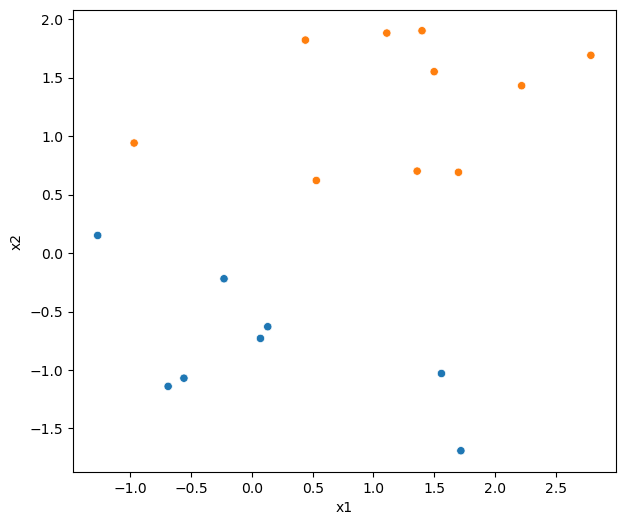

In [4]:
plt.figure(figsize=(7,6))
sns.scatterplot(x='x1', y='x2', hue='y', data=ex1, legend=False)
plt.show()

Now, let separate the features and outcome and encode the outcome to a binary vector. 

In [5]:
# Extracting the features and output and encoding y
X_ex1 = np.array(ex1.drop('y', axis=1))
y_ex1 = LabelEncoder().fit_transform(ex1.y)

print(X_ex1.shape)
print(y_ex1.shape)

(18, 2)
(18,)


### 🚩 Exercise 1 (CORE)

a. Create and fit an SVC model using a **linear kernel** and `C=100`.

b. Visualize the decision boundary, margin, and support vectors using the function `plot_margin` defined above. How many support vectors are there for each class? Are they on right side of the margin? hyperplane?

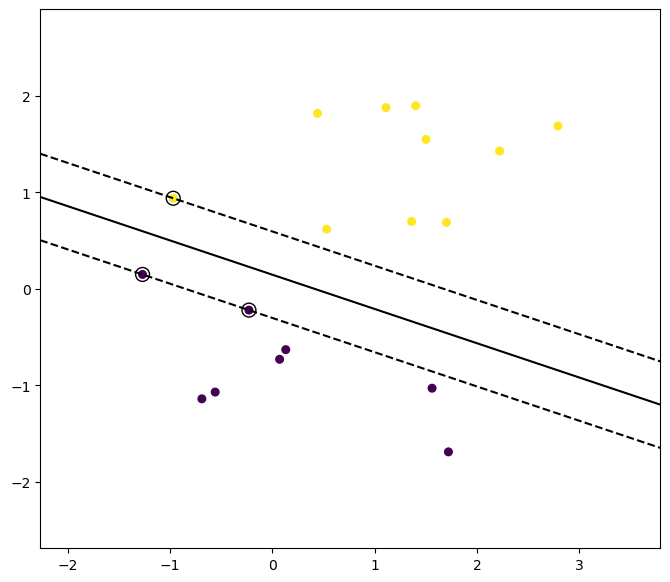

[2 1]


In [22]:
# Code for your answer here!
model=SVC(kernel='linear',C=100)
model.fit(X_ex1,y_ex1)
plot_margin(model, X_ex1, y_ex1, figsize=(8,7))
print(model.n_support_)

the number of support vector is 2,1. and on right side of the margin.

### 🚩 Exercise 2  (CORE)

Now, let's see how the results change with a small value of `C`.

a. Create and fit an SVC model using a **linear kernel** and `C=1`.

b. Visualize the decision boundary, margin, and support vectors. Now, how many support vectors are there for each class? Are they on right side of the margin? hyperplane? How has the margin changed?

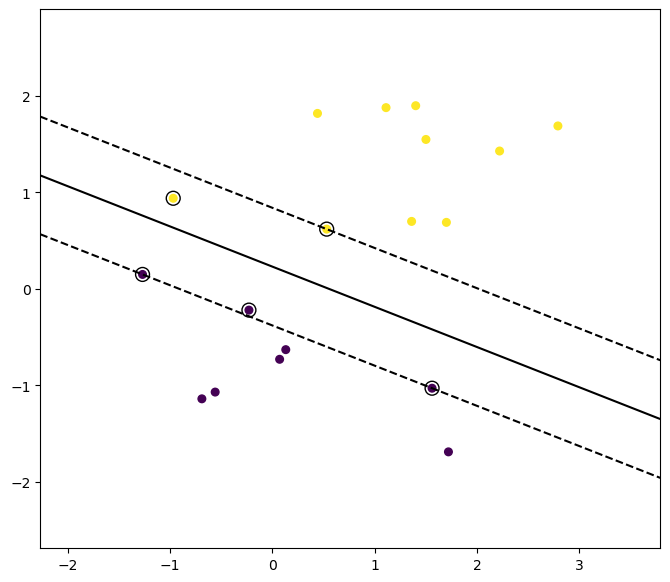

[3 2]


In [23]:
# Code for your answer here!
model1=SVC(kernel='linear',C=1)
model1.fit(X_ex1,y_ex1)
plot_margin(model1, X_ex1, y_ex1, figsize=(8,7))
print(model1.n_support_)

the number of support is 3,2.  but not on right side of the margin.

## Non-Separable Data

Next, we complicate our previous example by adding two additional points from class A to our data, which result in data that are no longer linearly separable. 

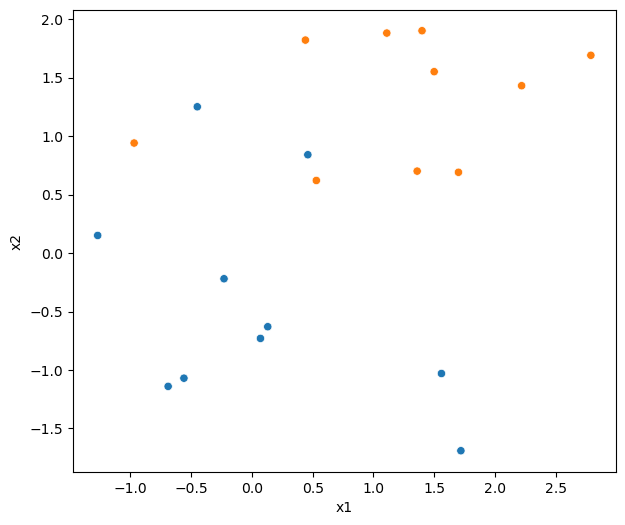

In [8]:
# Read in the data
ex2 = pd.read_csv("ex2.csv")

# Visualize the data
plt.figure(figsize=(7,6))
sns.scatterplot(x='x1', y='x2', hue='y', data=ex2, legend=False)
plt.show()

# Extracting the features and output and encoding y
X_ex2 = np.array(ex2.drop('y', axis=1))
y_ex2 = LabelEncoder().fit_transform(ex2.y)

### 🚩 Exercise 3  (CORE)

Fit the SVC model using the **linear kernel** and **same choices of `C=100` and `C=1`**. How have the results changed? Comment on changes related to the margin and the number of support vectors for each class and their location relative to the margin and hyperplane. 

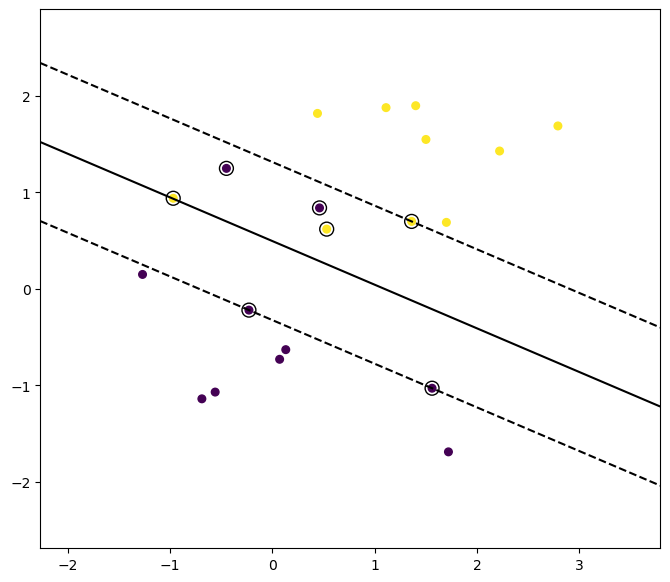

[4 3]


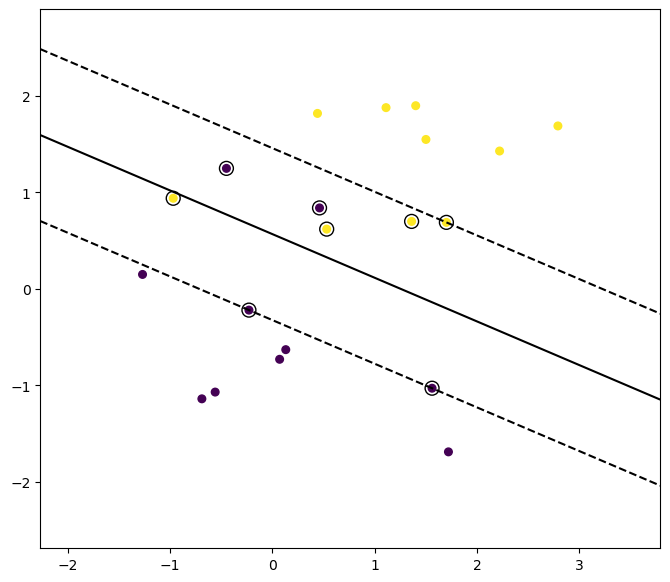

[4 4]


In [24]:
# Code for your answer here!
model3=SVC(kernel='linear',C=100)
model3.fit(X_ex2,y_ex2)
plot_margin(model3, X_ex2, y_ex2, figsize=(8,7))
print(model3.n_support_)
model4=SVC(kernel='linear',C=1)
model4.fit(X_ex2,y_ex2)
plot_margin(model4, X_ex2, y_ex2, figsize=(8,7))
print(model4.n_support_)

when C=100, a class's support vector on the hyperplane and when C=1 a class's exceed the hyperplane.

## Nonlinear Separation

Next, we will look at a new data set that is not linearly separable, but can be perfectly separated by a nonlinear decision boundary. We will start by loading and visualizing the data.

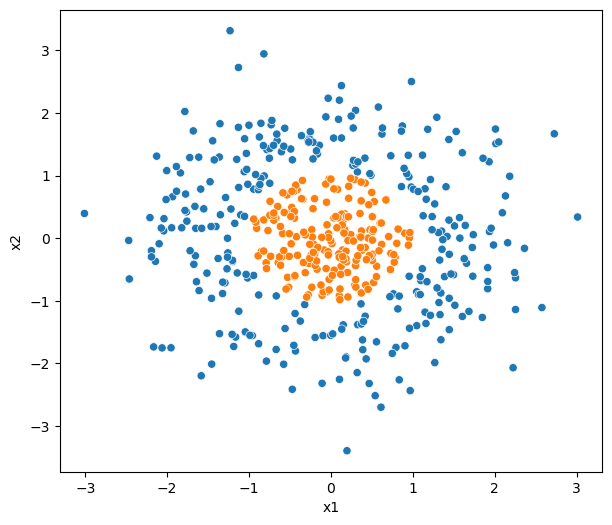

In [10]:
# Load the third data set
ex3 = pd.read_csv("ex3.csv")

# Visualize the data
plt.figure(figsize=(7,6))
sns.scatterplot(x='x1', y='x2', hue='y', data=ex3, legend=False)
plt.show()

# Extracting the features and output and encoding y
X_ex3 = np.array(ex3.drop('y', axis=1))
y_ex3 = LabelEncoder().fit_transform(ex3.y)

Let's start by trying to fit a linear SVC. As expected, the results are terrible and the number of support vectors is very large.

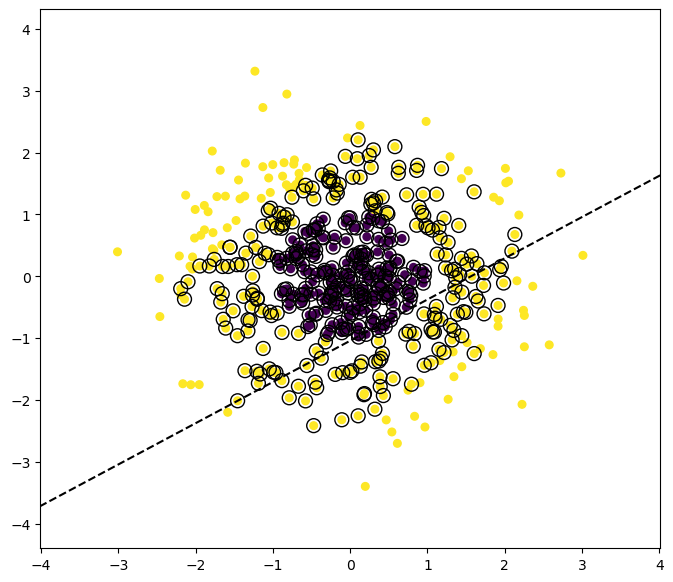

Number of support vectors for the linear model: [185 198]


In [11]:
# Fit the SVC with a linear kernel on the new data 
svm_lin = SVC(kernel='linear', C=100).fit(X_ex3, y_ex3)

# Visualize the decision boundary, margin and support vectors
plot_margin(svm_lin, X_ex3,y_ex3)

print('Number of support vectors for the linear model:', svm_lin.n_support_)

### 🚩 Exercise 4  (CORE)

- Fit an SVM with a **polynomial kernel with degree 2** and `C=100`.
- Visualize the margin and decision boundary and comment on the number of support vectors compared to the linear model.
- Compute and visualize the confusion matrix using `ConfusionMatrixDisplay.from_estimator`. Is the fitted SVM able to perfectly separate the classes?

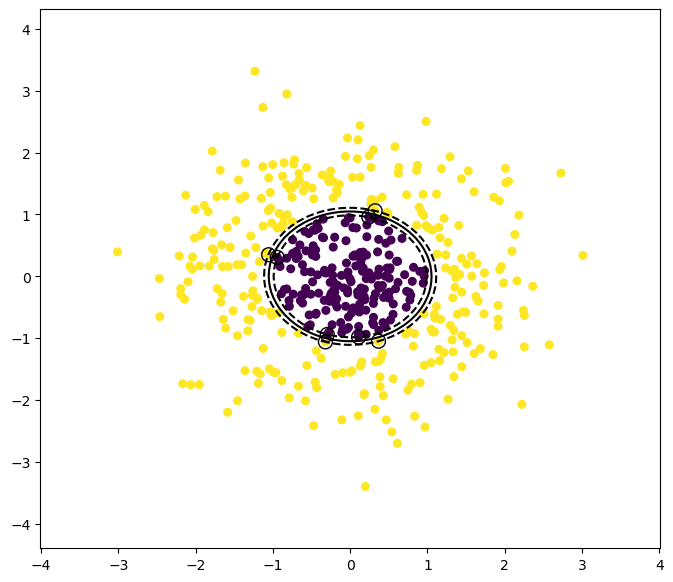

[4 4]


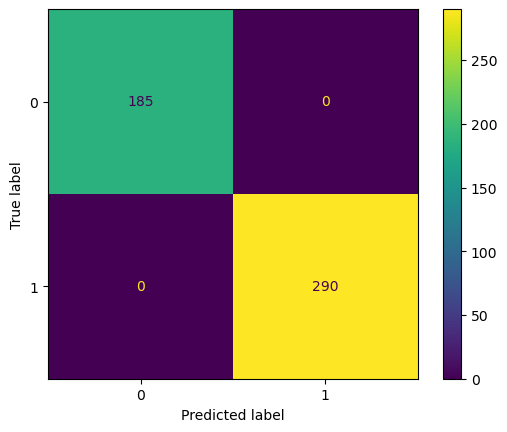

In [25]:
# Code for your answer here!
model5=SVC(kernel='poly',degree=2,C=100)
model5.fit(X_ex3,y_ex3)
plot_margin(model5, X_ex3, y_ex3, figsize=(8,7))
print(model5.n_support_)
ConfusionMatrixDisplay.from_estimator(model5,X_ex3,y_ex3)

it perfectly seperate the classes

## Kernels for SVMs and Parameter-Tuning

Next, we will consider an more complicated data, and explore using grid search to tune the model parameters and the effect of different kernels.


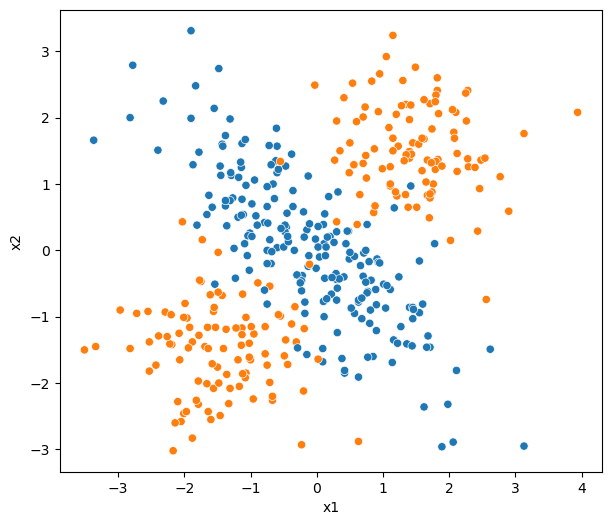

In [13]:
# Load the fourth data set
ex4 = pd.read_csv("ex4.csv")

# Visualize the data
plt.figure(figsize=(7,6))
sns.scatterplot(x='x1', y='x2', hue='y', data=ex4, legend=False)
plt.show()

# Extracting the features and output and encoding y
X_ex4 = np.array(ex4.drop('y', axis=1))
y_ex4 = LabelEncoder().fit_transform(ex4.y)

Let's start with the polynomial kernel that we saw in the previous exercise and use cross-validation to tune both the degree of polynomial and the penalty parameter.

In [28]:
# SVM with polynomial kernel
svm = SVC(kernel='poly', coef0=1)

# Grid search over C and the degree of the polynomial
degrees = [1,2,3,4]
C = np.linspace(0.1, 10, 100)
cv = GridSearchCV(
    svm,
    param_grid = {'C': C,
        'degree': degrees},
    cv = KFold(5, shuffle = True, random_state = 11205)
)

# Fit and tune the model
cv.fit(X_ex4, y_ex4)

# Get the best model parameters and the accuracy of the model
print("Params: ", cv.best_params_)
print("Avg Accuracy: ", cv.best_score_)

Params:  {'C': 0.4, 'degree': 3}
Avg Accuracy:  0.9325000000000001


### 🚩 Exercise 5  (CORE)

- Run the following code to plot the CV accuracy. Based on this plot, would you use the best parameter values printed above or choose different values? Why?
- Try changing the random state in `Kfold` to 11205 (or any other number of your choice). Do the best parameter values change? If so, why do you think this happens?
- For your selected parameters, fit the svm and plot the decision boundary and margin.

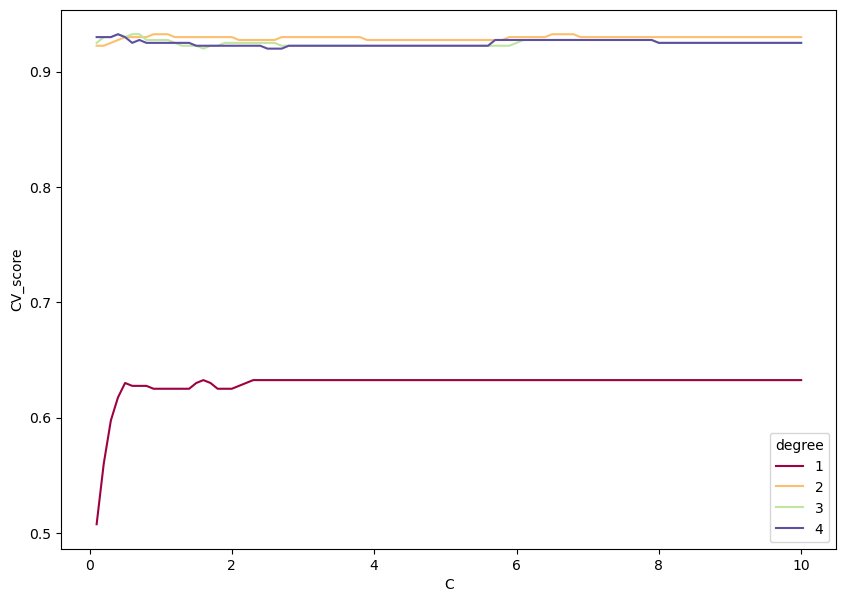

In [29]:
# Store cv scores in a data frame 
cv_accuracy = pd.DataFrame(cv.cv_results_
                           ).filter(['param_C', 'param_degree','mean_test_score']
                                    ).rename(columns={'param_C':'C', 'param_degree':'degree','mean_test_score':'CV_score'})

# Plot the CV scores
plt.figure(figsize=(10,7))
sns.lineplot(x='C', y='CV_score', data = cv_accuracy, hue ='degree', palette="Spectral") 
plt.show()

i chose C=4, and when kfold is 11205 chose C=3. it is because data split differenctly.

In [16]:
# Code for your answer here


### 🚩 Exercise 6  (CORE)

- Repeat the grid search above with a polynomial kernel but set the coefficent term `coef0=0` (this is the default value). Redraw the plot of the CV accuracy. How have the results changed? Can you explain why?

In [17]:
# Code for your answer here

_Type your answer here_

### 🚩 Exercise 7  (CORE)

Consider instead the RBF kernel. 

- Use grid search to tune both the penalty parameter $C$ and the inverse bandwidth parameter $\gamma$.

- Plot the decision boundary. How do the results compare to the SVM with a polynomial kernel?

In [18]:
#  Code for your answer here

_Type your answer here_

##  Model Assessment <a id='asses'></a>

As, we learned last week, there are many metrics to consider beyond accuracy. For example, below we compute and print the classification report, summarizing the results for precision, recall, f1-score, and accuracy. 

In [19]:
from sklearn.metrics import classification_report

# Classification report for the SVM with polynomial kernel
print(classification_report(y_ex4, cv.best_estimator_.predict(X_ex4)))

# Classification report for the SVM with RBF kernel
print(classification_report(y_ex4, cv2.best_estimator_.predict(X_ex4)))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       200
           1       0.97      0.92      0.94       200

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400



NameError: name 'cv2' is not defined


We also learned about other tools, such as the ROC curve, AUC, and precision-recall curve. However, since the SVMs are not model-based, **we only obtain hard label assignments when doing predictions**. To overcome this, one heuristic that can be used is **Platt scaling** to convert the SVM output to probabilities. However, these probabilites may not be well calibrated and may be inconsistent with the hard labels.

In the code below, we visualize the probabilities of class assignments across a grid of possible inputs for the tuned SVM polynomial model. 

In [ ]:
# Fit the polynomial model with optimal prarmeters and the option to compute the probabilities
svm_poly = SVC(kernel='poly', C=cv.best_params_["C"], degree=cv.best_params_["degree"], probability=True).fit(X_ex4, y_ex4)

# Create a grid of inputs for plotting
x1lim = [X_ex4[:,0].min(),X_ex4[:,0].max()]
x2lim = [X_ex4[:,1].min(),X_ex4[:,1].max()]
    
xx1 = np.linspace(x1lim[0]-1, x1lim[1]+1, 50)
xx2 = np.linspace(x2lim[0]-1, x2lim[1]+1, 50)
XX2, XX1 = np.meshgrid(xx2, xx1)
    
# Calculate the probabiltiy for each point in the grid
xx = np.c_[XX1.ravel(), XX2.ravel()]
xx.shape
P = svm_poly.predict_proba(xx)[:,0].reshape(XX1.shape)

plt.figure(figsize=(8,6))
plt.contourf(XX1, XX2, P)
plt.colorbar()
plt.scatter(x=X_ex4[:,0], y=X_ex4[:,1],c = 1-y_ex4, marker = '.')
plt.show()

Notice how the model is quite **confident in the predictions (probabilities close to 0 or 1)** in the corners of the input space, even where we don't have any data.  In some cases, this may be undesirable, as we may not want to make such confident assesments in areas where we have little to no data.

### 🚩 Exercise 8  (EXTRA)

- For the SVM with RBF kernel and optimal CV parameters, repeat the plot above to visualize the probabilities of class assignments.
- How do the results compare with the polynomial kernel? Does this impact your choice of kernel?

In [ ]:
# Code for your answer here

_Type your answer here_

# Spam Data <a id='spam'></a>

Let's consider the spam data available on [kaggle](https://www.kaggle.com/datasets/tmehul/spamcsv). The dataset includes thousands of messages that have been marked as `spam` or `ham`. We will start by loading and exploring the data.

In [ ]:
# Load the data
df = pd.read_csv("spam.csv", encoding='latin-1')

# Check information about the dataset
print(df.info())

Let's do some basic data cleaning.

In [ ]:
# Drop unnecessary columns
columns_to_drop = ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]
df.drop(columns=columns_to_drop, inplace=True)

# Rename columns for better readability
new_column_names = {"v1": "Category", "v2": "Message"}
df.rename(columns=new_column_names, inplace=True)

print(df.info())

Looking at the first few rows of the data (below), we see that we will need to do some feature engineering to covert the text messages into numeric features. 

In [ ]:
df.head()

Let's start by splitting our data into features and targets. Notice that the dataset contains, as expected, less spam emails than ham. 

In [ ]:
# Split the dataset into features (X) and target (y)
X = df["Message"]
y = df["Category"]

plt.figure(figsize=(5,5))
sns.countplot(x=y)
plt.show()

We are going to use a simple **bag of words** transformation to convert our message to numeric features through sklearn's transformer: [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html). 

We will incorporate it into our pipeline later, but you can run the code below to get a sense of how it transforms the messages. 

For simplicity, we set:
- `binary=True` which returns binary features indicating the presence/absence of the words in the vocabulary
- `max_features=50` and `stop_words="english"` which automatically extracts the vocabulary as the 50 most frequent words among the messages, excluding common english words like  “and”, “the”, “him”.

We can print the attribute `.vocabulary_` of our fitted transformer to see the words of our vocabulary.

In [ ]:
# Create count vectorizer for bag of words feature extraction
from sklearn.feature_extraction.text import CountVectorizer

fe = CountVectorizer(max_features=50, stop_words="english", binary=True).fit(X)
X_ = fe.transform(X)

# print vocabulary
fe.vocabulary_

To visualize the transformed data, let's also draw a heatmap of first 100 messages for spam and ham messages.

In [ ]:
# Draw a heatmap of the first 100 messages
feature_names = fe.get_feature_names_out()
X_pd_spam = pd.DataFrame(
    X_.toarray()[y=='spam',:][0:100,:],
    columns=feature_names
)
X_pd_ham = pd.DataFrame(
    X_.toarray()[y=='ham',:][0:100,:],
    columns=feature_names
)

fig, ax = plt.subplots(2,1,figsize=(10,6))
sns.heatmap(X_pd_spam, cmap='Blues', vmin=0, vmax=1, ax=ax[0])
ax[0].set_xlabel('Word feature')
ax[0].set_ylabel('Messages')
ax[0].set_title('Spam')
ax[0].set_xticks(np.arange(len(feature_names)), labels = feature_names)
sns.heatmap(X_pd_ham, cmap='Blues', vmin=0, vmax=1, ax=ax[1])
ax[1].set_xlabel('Word feature')
ax[1].set_ylabel('Messages')
ax[1].set_title('Ham')
ax[1].set_xticks(np.arange(len(feature_names)), labels = feature_names)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Next, we split the data into a train and test set. Due to the class imbalance in the data, we use the option `stratify=y` to maintain the class proportion in the test set.

In [ ]:
from sklearn.model_selection import train_test_split

y = LabelEncoder().fit_transform(y)

# Stratify split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle= True, stratify=y,
                                                    test_size = 0.1, random_state=1112)
print(X_train.shape)
print('Proportion of spam in training', np.mean(y_train))
print('Proportion of spam in test', np.mean(y_test))

### 🚩 Exercise 9 (CORE)

a. Run the following code to fit an SVC and tune the penalty parameter `C`.

b. Plot the accuracy, recall, precision, and f1 score as function of `C`. What value of `C` would you choose and why?

In [ ]:
from sklearn.model_selection import StratifiedKFold

# SVM with linear kernel
svm_lin = make_pipeline(
    CountVectorizer(max_features=50, stop_words="english", binary=True),
    SVC(kernel='linear')
)

# Grid search over C 
C = np.linspace(0.1, 10, 20)
cv_lin = GridSearchCV(
    svm_lin,
    param_grid = {'svc__C': C},
    cv = StratifiedKFold(5, shuffle = True, random_state = 0),
    scoring = ["accuracy", "f1","recall","precision"],
    refit='accuracy' #refit based on accuracy
)

# Fit and tune the model
cv_lin.fit(X_train, y_train)

# Store cv scores in a data frame 
cv_accuracy = pd.DataFrame(cv_lin.cv_results_
                           ).filter(['param_svc__C','mean_test_accuracy','mean_test_f1', 'mean_test_recall', 'mean_test_precision']
                                    ).rename(columns={'param_svc__C':'C','mean_test_accuracy':'CV accuracy', 'mean_test_f1':'CV f1', 'mean_test_recall':'CV recall', 'mean_test_precision':'CV precision'})

In [ ]:
# Code for your answer here

_Type your answer here_

### 🚩 Exercise 10 (CORE)

a. Refit the model with your chosen value of `C`. You should call your model `svm_lin` or change the name in code for part b.

b. Run the code the below to visualize the coefficients and the support vectors for each class. Briefly comment on words/features that are relevant for distinguishing between the classes. 

In [ ]:
# Part a: code for your answer here
# Name your model svm_lin or change the name in the code below


In [ ]:
# Plot the coefficients of the linear SVC
feature_names = svm_lin[:-1].get_feature_names_out()
w = svm_lin[-1].coef_.toarray().reshape(-1)

df = pd.DataFrame({'feature': feature_names, 'coef': w}).sort_values ("coef", ascending=False)

plt.figure(figsize=(10,4))
plt.bar(df['feature'], df['coef'])
plt.title('Coefficient Estimates')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=90)
plt.grid()
plt.show()

In [ ]:
# Draw a heatmap of the support vectors in each class
sv = svm_lin[-1].support_vectors_.toarray() # support vectors
sv_idx = svm_lin[-1].support_ # indices of support vectors
sv_labels = y_train[sv_idx] # labels of support vectors
sv_spam = pd.DataFrame(
    sv[sv_labels == 1,:],
    columns=feature_names
)
sv_ham = pd.DataFrame(
   sv[sv_labels == 0,:],
    columns=feature_names
)

fig, ax = plt.subplots(2,1,figsize=(10,10))
sns.heatmap(sv_spam, cmap='Blues', vmin=0, vmax=1, ax=ax[0])
ax[0].set_xlabel('Word feature')
ax[0].set_ylabel('Messages')
ax[0].set_title('Spam')
ax[0].set_xticks(np.arange(len(feature_names)), labels = feature_names)
sns.heatmap(sv_ham,  cmap='Blues', vmin=0, vmax=1, ax=ax[1])
ax[1].set_xlabel('Word feature')
ax[1].set_ylabel('Messages')
ax[1].set_title('Ham')
ax[1].set_xticks(np.arange(len(feature_names)), labels = feature_names)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

_Type your answer here_

### 🚩 Exercise 11 (CORE)

Now, let's explore using a nonlinear decision boundary:
- Alter your pipeline from the previous exercise to use a polynomial kernel of degree 2 with a coefficient of 1. 
- Tune the parameter `C`. 
- Display the confusion matrix on the test data for both models. How do the results compare?

In [ ]:
# Code for your answer here

_Type your answer here_

### 🚩 Exercise 12 (CORE)

Try increasing the maximum number of features extracted in the bag of words for the linear SVM.  
- Visualize the differences between the support vectors for the two classes. Are there any changes to the words which are relevant to distinguishing between the classes?
- How do the results compare on thwe test data?

In [ ]:
# Code for your answer here

_Type your answer here_

### 🚩 Exercise 13 (EXTRA)

Lastly, try tuning also the number of features in your CV grid search, with a search over values of `C = np.array([0.1,1,5,10])` and `max_features = np.arange(50,500,10)`. 
- By comparing the different metrics, which value of `C` and `max_features` would you choose? 
- Fit the model with your selected values, and display the confusion matrix for the test data. How do the results compare to the previous models?

In [ ]:
# Code for your answer here
C = np.array([0.1,1,5,10])
max_features = np.arange(50,500,10)


_Type your answer here_

# Competing the Worksheet

At this point you have hopefully been able to complete all the CORE exercises and attempted the EXTRA ones. Now 
is a good time to check the reproducibility of this document by restarting the notebook's
kernel and rerunning all cells in order.


Before generating the PDF, please **change 'Student 1' and 'Student 2' at the top of the notebook to include your name(s)**.

Once that is done and you are happy with everything, you can then run the following cell 
to generate your PDF. Once generated, please submit this PDF on Learn page by 16:00 PM on the Friday of the week the workshop was given. 

In [ ]:
!jupyter nbconvert --to pdf mlp_week07.ipynb 